In [4]:
def run_anom_exp(new_knowns, new_unknowns,features_to_use,std_scale, rebalance_knowns):
    subclasses = np.concatenate([new_knowns, new_unknowns])
    top_level_df = commondat[commondat['class'].isin(subclasses)]
    top_level_df = top_level_df.loc[:,list(features_to_use)+["class"]].dropna(subset=features_to_use)
    top_level_df = top_level_df[~top_level_df.index.duplicated(keep='first')]
    
    inlier_df = top_level_df[top_level_df["class"].isin(myknowns)]
    
    if rebalance_knowns:
        smallest_class_count = inlier_df["class"].value_counts().min()
        keep_indices = inlier_df.groupby("class").sample(smallest_class_count).index
        inlier_df=inlier_df[inlier_df.index.isin(keep_indices)]
        thrown_inlier_df = inlier_df[~inlier_df.index.isin(keep_indices)]
    
    outlier_df = top_level_df[top_level_df["class"].isin(myunknowns)]

    if len(outlier_df) == 0:
        raise(f"\tSkipping {anomaly_subclass}, no samples found.")

    # First split inliers into train/test
    inlier_train_df, inlier_test_df = train_test_split(
        inlier_df, test_size=0.2, random_state=seed_val,
        stratify=inlier_df['class'],
    )
    
    X_train_df = inlier_train_df[features_to_use]
    X_train = X_train_df.to_numpy()
    y_train_df = inlier_train_df['class']
    y_train = y_train_df.to_numpy()

    if rebalance_knowns:
        inlier_test_df = pd.concat([inlier_test_df,thrown_inlier_df])

    # Add outliers to test only
    X_test_inliers_df = inlier_test_df[features_to_use]
    X_test_outliers_df = outlier_df[features_to_use]
    X_test_df = pd.concat([X_test_inliers_df, X_test_outliers_df])
    X_test = X_test_df.to_numpy()

    y_test_df = top_level_df.loc[X_test_df.index,"class"]
    y_test = y_test_df.to_numpy()

    results_df = pd.DataFrame(index=X_test_df.index)
    results_df['class'] = y_test_df
    mask = results_df['class'].isin(new_knowns)
    results_df['status'] = np.where(mask, 'normal', 'anomalous')
    
    # # STD SCALER
    if std_scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    for model_name, model in tqdm(models_to_test.items(), desc=f"Models", leave=False):
        if "DistClassiPy" in model_name or "ClassSVDD" or "DeepSVDD" in model_name:
            model.fit(X_train, y_train)
        else:
            model.fit(X_train)
        scores = model.decision_function(X_test)
        if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
            scores = -scores # Lower is more anomalous for these, so we flip

        results_df[f'score_{model_name}'] = scores

    return results_df

In [5]:
def analysis(results_df):

    # --- 1. Plot for purity v/s budget ---
    max_anom = results_df["status"].value_counts()["anomalous"]
    top_n = min(200, max_anom)
        
    methods_percent = {}
    top_ns = np.arange(start=1, stop=top_n+1)
    
    for model_name in tqdm(models_to_test.keys(),desc="method",leave=False):
        methods_percent[model_name] = []
        topresults_df = results_df.sort_values(by=f"score_{model_name}",ascending=False).iloc[:top_n]
        for i in tqdm(range(len(topresults_df)), leave=False):
            top_candidates = topresults_df.head(i)
            valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
            if "anomalous" in valcounts.index:
                frac = valcounts["anomalous"]
                # frac = valcounts["anomalous"] / len(y_anom_df)
            else:
                frac = 0
            methods_percent[model_name].append(frac)
        plt.plot(top_ns, methods_percent[model_name][:top_n], label=model_name, linewidth=2)
    plt.ylabel("Purity", fontsize=16)
    plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
    plt.gca().tick_params(axis='both', which='major', labelsize=16)
    plt.gca().tick_params(axis='both', which='minor', labelsize=12)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
    # plt.savefig(f"top{endnum}budget4methods.png",dpi=300,bbox_inches="tight")
    return plt.gca()

Calculating correlations...
Done!
SPM_chi_u
Harmonics_mse_r
Multiband_period
Harmonics_mag_2_r
SPM_t0_r
SPM_gamma_z
SPM_beta_u
SPM_tau_rise_Y
n_forced_phot_band_before_r
n_forced_phot_band_after_Y
PPE
Period_band_i
Power_rate_1_4
Power_rate_1_3
Power_rate_1_2
Power_rate_2
Power_rate_3
Power_rate_4
Harmonics_phase_2_r
Harmonics_phase_3_r
Harmonics_phase_4_r
Harmonics_phase_5_r
Harmonics_phase_6_r
Harmonics_phase_7_r
Harmonics_phase_2_i
Harmonics_phase_3_i
Harmonics_phase_4_i
Harmonics_phase_5_i
Harmonics_phase_6_i
Harmonics_phase_7_i
SPM_A_u
SPM_tau_fall_u
SPM_A_g
SPM_tau_fall_g
SPM_tau_fall_r
SPM_tau_fall_i
SPM_tau_fall_z
SPM_tau_fall_Y
SPM_chi_g
SPM_chi_z
SPM_chi_Y


SFS:   0%|          | 0/16 [00:00<?, ?it/s]

/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distances.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(u - v)) / np.sum(np.minimum(u, v))
/Users/sidchaini/Research/DistClassiPy/distclassipy/distance

EFS:   0%|          | 0/1 [00:00<?, ?it/s]

['SPM_A_g', 'SPM_beta_u', 'SPM_chi_u', 'SPM_gamma_z', 'SPM_tau_fall_g', 'SPM_tau_fall_i', 'SPM_tau_fall_r', 'SPM_tau_fall_z', 'SPM_tau_rise_Y']


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

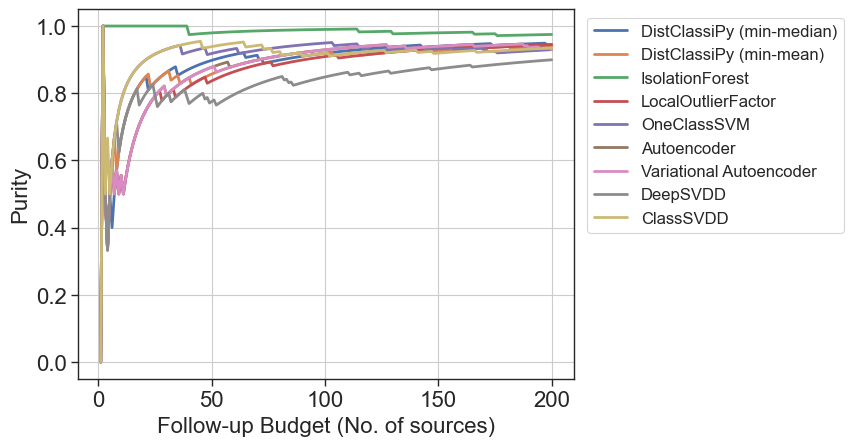

In [6]:
myknowns = [
    "SNIax",
    "SNIa-91bg",
    "SNIa-SALT3",
    "SNIc-Templates",
    "SNIc+HostXT_V19",
    "SNIcBL+HostXT_V19",
    "SNIb-Templates",
    "SNIb+HostXT_V19",
    "SNIIb+HostXT_V19",
    "SNIIn+HostXT_V19"
    "SNIIn-MOSFIT",
    "SNII+HostXT_V19"
]

myunknowns = ["PISN-STELLA_HYDROGENIC",
"SLSN-I_no_host",
"SLSN-I+host",
"ILOT",
"CART",
"uLens-Single_PyLIMA",
"uLens-Single-GenLens",
"KN_B19",
"KN_K17",
"SL-SN1a",
"SL-SNII",
"SL-SNIc",
"SL-SNIb",
"PISN-MOSFIT",
"PISN-STELLA_HECORE"]

features_df=commondat[commondat["class"].isin(myknowns)]
class_df=features_df.loc[:,"class"]
features_df=features_df.drop("class", axis=1)
features_df=features_df.drop(
    ["Timespan", "Coordinate_x", "Coordinate_y", "Coordinate_z"],
    axis=1,
)

smallfeatures, class_df = utils.remove_correlated_features(features_df,class_df, corr_thresh = 0.8, rebalance=False)

for c in smallfeatures.columns:
    print(c)
myfeatures = utils.get_lcdc_features(smallfeatures, class_df, dcpy._UNIQUE_METRICS, k_features=10)
print(myfeatures)

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

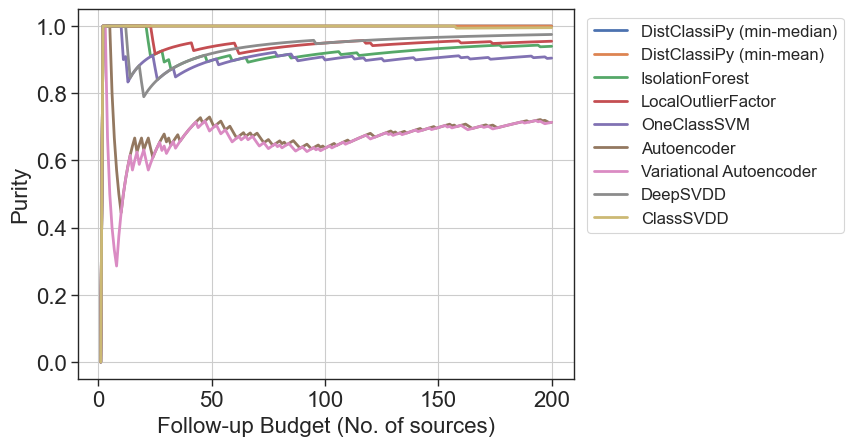

In [7]:
myknowns = ['EB', 'DSCT', 'RRL', 'CEP']
myunknowns = ['PISN-STELLA_HYDROGENIC', 'PISN-MOSFIT', 'uLens-Single_PyLIMA',
        'TDE', 'SNIcBL+HostXT_V19', 'KN_B19', 'uLens-Binary', 'SL-SNII',
        'SNIc-Templates', 'SLSN-I+host', 'SNIa-SALT3', 'SNIb-Templates',
        'SNII+HostXT_V19', 'SNIa-91bg', 'SL-SNIb', 'Mdwarf-flare', 'ILOT',
        'KN_K17', 'CART', 'SNIIb+HostXT_V19', 'SNIb+HostXT_V19', 'SL-SN1a',
        'SNII-NMF', 'SNIIn+HostXT_V19', 'SNII-Templates',
        'SNIc+HostXT_V19', 'SNIax', 'SNIIn-MOSFIT', 'uLens-Single-GenLens',
        'PISN-STELLA_HECORE', 'AGN', 'SLSN-I_no_host', 'SL-SNIc',
        'dwarf-nova']

myfeatures = [
    "SPM_A_Y",
    "Multiband_period",
    "r-i",
    "Harmonics_phase_4_i",
    "Harmonics_phase_2_r",
    "Power_rate_4",
]

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

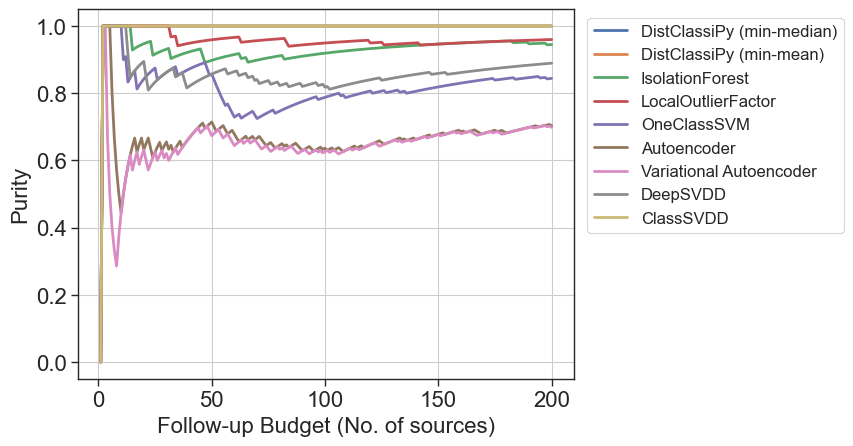

In [8]:
myknowns = ['EB', 'DSCT', 'RRL', 'CEP']
myunknowns = ['PISN-STELLA_HYDROGENIC', 'PISN-MOSFIT', 'uLens-Single_PyLIMA',
        'TDE', 'SNIcBL+HostXT_V19', 'KN_B19', 'uLens-Binary', 'SL-SNII',
        'SNIc-Templates', 'SLSN-I+host', 'SNIa-SALT3', 'SNIb-Templates',
        'SNII+HostXT_V19', 'SNIa-91bg', 'SL-SNIb', 'Mdwarf-flare', 'ILOT',
        'KN_K17', 'CART', 'SNIIb+HostXT_V19', 'SNIb+HostXT_V19', 'SL-SN1a',
        'SNII-NMF', 'SNIIn+HostXT_V19', 'SNII-Templates',
        'SNIc+HostXT_V19', 'SNIax', 'SNIIn-MOSFIT', 'uLens-Single-GenLens',
        'PISN-STELLA_HECORE', 'AGN', 'SLSN-I_no_host', 'SL-SNIc',
        'dwarf-nova']

myfeatures = [
    "SPM_A_Y",
    "Multiband_period",
    "r-i",
    "Harmonics_phase_4_i",
    "Harmonics_phase_2_r",
    "Power_rate_4",
]

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

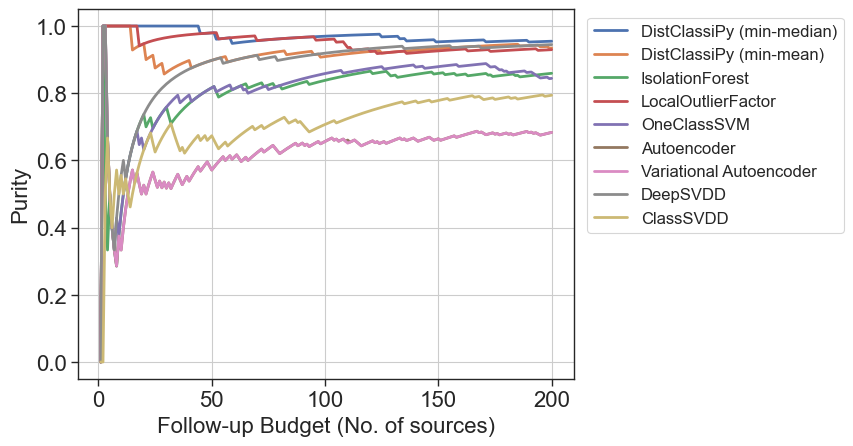

In [9]:
myknowns = ['EB', 'DSCT', 'RRL', 'CEP']
myunknowns = ['PISN-STELLA_HYDROGENIC', 'PISN-MOSFIT', 'uLens-Single_PyLIMA',
        'TDE', 'SNIcBL+HostXT_V19', 'KN_B19', 'uLens-Binary', 'SL-SNII',
        'SNIc-Templates', 'SLSN-I+host', 'SNIa-SALT3', 'SNIb-Templates',
        'SNII+HostXT_V19', 'SNIa-91bg', 'SL-SNIb', 'Mdwarf-flare', 'ILOT',
        'KN_K17', 'CART', 'SNIIb+HostXT_V19', 'SNIb+HostXT_V19', 'SL-SN1a',
        'SNII-NMF', 'SNIIn+HostXT_V19', 'SNII-Templates',
        'SNIc+HostXT_V19', 'SNIax', 'SNIIn-MOSFIT', 'uLens-Single-GenLens',
        'PISN-STELLA_HECORE', 'AGN', 'SLSN-I_no_host', 'SL-SNIc',
        'dwarf-nova']

myfeatures = ['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
       'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
    'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r',]

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

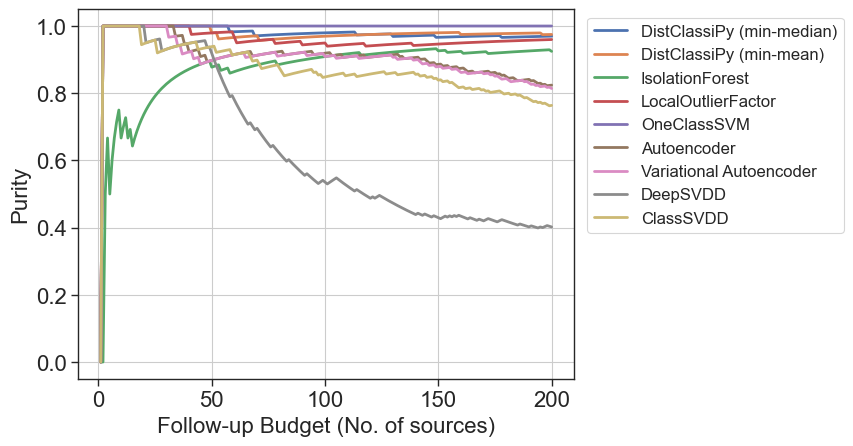

In [10]:
myknowns = ['EB', 'DSCT', 'RRL', 'CEP']
myunknowns = ['PISN-STELLA_HYDROGENIC', 'PISN-MOSFIT', 'uLens-Single_PyLIMA',
        'TDE', 'SNIcBL+HostXT_V19', 'KN_B19', 'uLens-Binary', 'SL-SNII',
        'SNIc-Templates', 'SLSN-I+host', 'SNIa-SALT3', 'SNIb-Templates',
        'SNII+HostXT_V19', 'SNIa-91bg', 'SL-SNIb', 'Mdwarf-flare', 'ILOT',
        'KN_K17', 'CART', 'SNIIb+HostXT_V19', 'SNIb+HostXT_V19', 'SL-SN1a',
        'SNII-NMF', 'SNIIn+HostXT_V19', 'SNII-Templates',
        'SNIc+HostXT_V19', 'SNIax', 'SNIIn-MOSFIT', 'uLens-Single-GenLens',
        'PISN-STELLA_HECORE', 'AGN', 'SLSN-I_no_host', 'SL-SNIc',
        'dwarf-nova']

myfeatures = [
'SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 'SPM_A_i',
'SPM_gamma_i', 'SPM_beta_i', 'SPM_tau_rise_i', 'SPM_tau_fall_i',
'SPM_A_z', 'SPM_gamma_z', 'SPM_beta_z', 'SPM_tau_rise_z',
'SPM_tau_fall_z', 'SPM_A_Y', 'SPM_gamma_Y', 'SPM_beta_Y',
'SPM_tau_rise_Y', 'SPM_tau_fall_Y', 'SPM_chi_r', 'SPM_chi_i',
'SPM_chi_z'
]

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

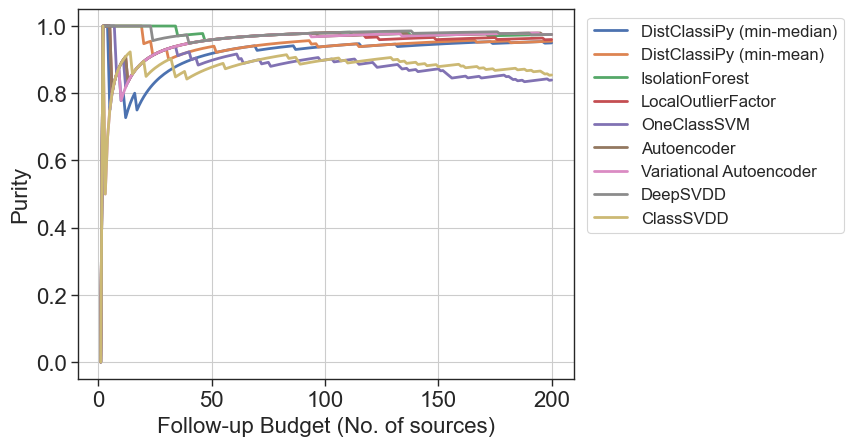

In [11]:
myknowns = ["SNIax",
"SNIa-91bg",
"SNIa-SALT3",
"SNIc-Templates",
"SNIc+HostXT_V19",
"SNIcBL+HostXT_V19",
"SNIb-Templates",
"SNIb+HostXT_V19",
"SNIIb+HostXT_V19",
"SNIIn+HostXT_V19"
"SNIIn-MOSFIT",
"SNII+HostXT_V19"]

myunknowns = ["PISN-STELLA_HYDROGENIC",
"SLSN-I_no_host",
"SLSN-I+host",
"ILOT",
"CART",
"uLens-Single_PyLIMA",
"uLens-Single-GenLens",
"KN_B19",
"KN_K17",
"SL-SN1a",
"SL-SNII",
"SL-SNIc",
"SL-SNIb",
"PISN-MOSFIT",
"PISN-STELLA_HECORE"]


myfeatures = ['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 'SPM_A_i',
'SPM_gamma_i', 'SPM_beta_i', 'SPM_tau_rise_i', 'SPM_tau_fall_i',
'SPM_A_z', 'SPM_gamma_z', 'SPM_beta_z', 'SPM_tau_rise_z',
'SPM_tau_fall_z', 'SPM_A_Y', 'SPM_gamma_Y', 'SPM_beta_Y',
'SPM_tau_rise_Y', 'SPM_tau_fall_Y', 'SPM_chi_r', 'SPM_chi_i',
'SPM_chi_z']

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

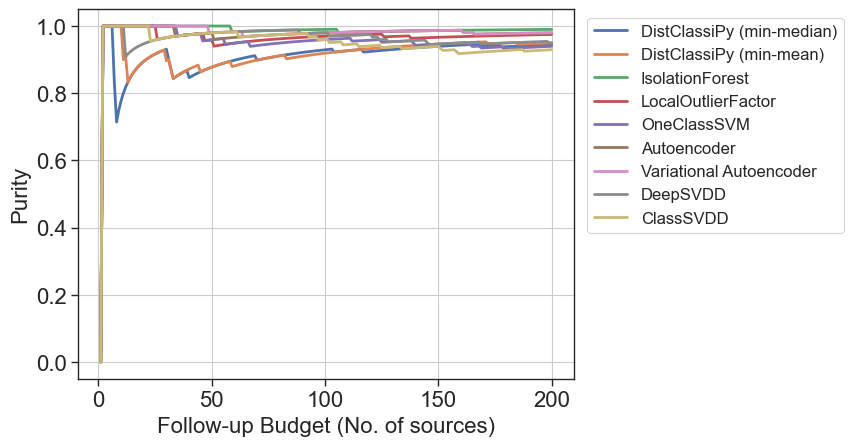

In [12]:
myknowns = ["SNIax",
"SNIa-91bg",
"SNIa-SALT3",
"SNIc-Templates",
"SNIc+HostXT_V19",
"SNIcBL+HostXT_V19",
"SNIb-Templates",
"SNIb+HostXT_V19",
"SNIIb+HostXT_V19",
"SNIIn+HostXT_V19"
"SNIIn-MOSFIT",
"SNII+HostXT_V19"]

myunknowns = ["PISN-STELLA_HYDROGENIC",
"SLSN-I_no_host",
"SLSN-I+host",
"ILOT",
"CART",
"uLens-Single_PyLIMA",
"uLens-Single-GenLens",
"KN_B19",
"KN_K17",
"SL-SN1a",
"SL-SNII",
"SL-SNIc",
"SL-SNIb",
"PISN-MOSFIT",
"PISN-STELLA_HECORE"]


myfeatures = ['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
       'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
    'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 
]


results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

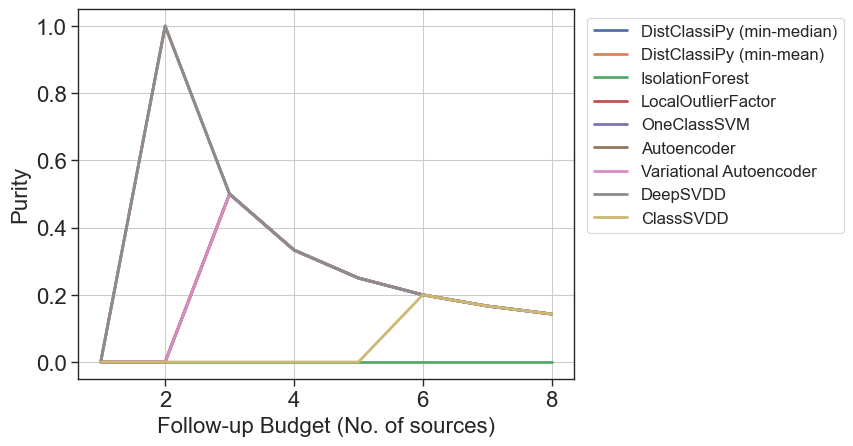

In [13]:
myknowns = [
"SNIax",
"SNIa-91bg",
"SNIa-SALT3",
"SNIc-Templates",
"SNIc+HostXT_V19",
"SNIcBL+HostXT_V19",
"SNIb-Templates",
"SNIb+HostXT_V19",
"SNIIb+HostXT_V19",
"SNIIn+HostXT_V19"
"SNIIn-MOSFIT",
"SNII+HostXT_V19",
]

myunknowns = [
"KN_B19",
"KN_K17",
]



myfeatures = [
'SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 'SPM_A_i',
'SPM_gamma_i', 'SPM_beta_i', 'SPM_tau_rise_i', 'SPM_tau_fall_i',
'SPM_A_z', 'SPM_gamma_z', 'SPM_beta_z', 'SPM_tau_rise_z',
'SPM_tau_fall_z', 'SPM_A_Y', 'SPM_gamma_Y', 'SPM_beta_Y',
'SPM_tau_rise_Y', 'SPM_tau_fall_Y', 'SPM_chi_r', 'SPM_chi_i',
'SPM_chi_z',
]

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping triggered.


...

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

<Axes: xlabel='Follow-up Budget (No. of sources)', ylabel='Purity'>

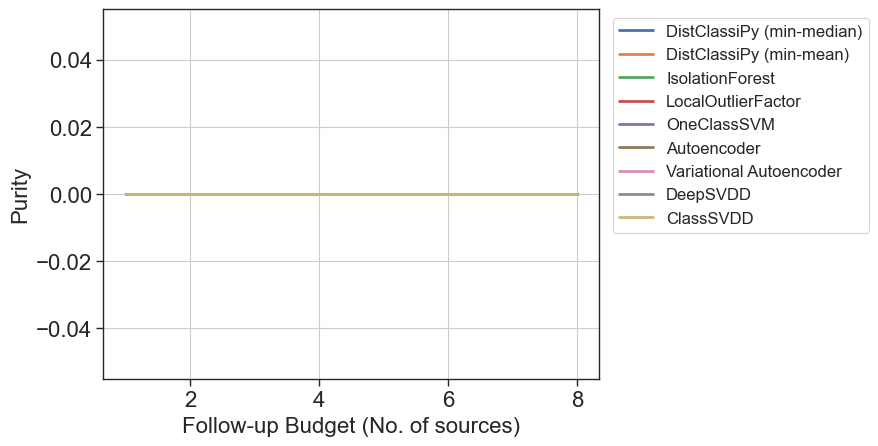

In [14]:
myknowns = [
"SNIax",
"SNIa-91bg",
"SNIa-SALT3",
"SNIc-Templates",
"SNIc+HostXT_V19",
"SNIcBL+HostXT_V19",
"SNIb-Templates",
"SNIb+HostXT_V19",
"SNIIb+HostXT_V19",
"SNIIn+HostXT_V19"
"SNIIn-MOSFIT",
"SNII+HostXT_V19",
]

myunknowns = [
"KN_B19",
"KN_K17",
]



myfeatures = ['SPM_A_g', 'SPM_gamma_g', 'SPM_beta_g',
       'SPM_tau_rise_g', 'SPM_tau_fall_g', 'SPM_A_r', 'SPM_gamma_r',
    'SPM_beta_r', 'SPM_tau_rise_r', 'SPM_tau_fall_r', 
]

results_df = run_anom_exp(
    new_knowns=myknowns, 
    new_unknowns=myunknowns,
    features_to_use=myfeatures,
    std_scale=False,
    rebalance_knowns=True,
)

analysis(results_df)

### sid thoughts:
- find best features for a problem through classification in a function
- run concrete transient anomaly examples
- try feature selection through best classification features on known classes
- try real ztf data